In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv('sales_data.csv')
df.head()

,Shop Name,Product Name,Product Category,Quantity Sold,Price Per Unit,Total Sales
0,Urban Tech,Wireless Mouse,Tech,2,25.00,50.00
1,Daily Grocer,Organic Milk,Daily Use,5,4.50,22.50
2,The Snack Shack,Potato Chips,Snacks,12,2.99,35.88
3,Metro Electronics,USB Cable,Tech,8,8.99,71.92
4,Pantry Essentials,Dish Soap,Household,3,3.75,11.25


In [4]:
df.describe()

,Quantity Sold,Price Per Unit,Total Sales
count,100.000000,100.000000,100.000000
mean,6.460000,19.722000,54.326000
std,5.127506,31.812975,42.428859
min,1.000000,0.990000,9.990000
25%,2.000000,3.930000,24.937500
50%,5.000000,7.990000,37.560000
75%,9.250000,18.990000,74.977500
max,25.000000,199.990000,239.980000


In [5]:
df.isna().sum()

Shop Name           0
Product Name        0
Product Category    0
Quantity Sold       0
Price Per Unit      0
Total Sales         0
dtype: int64

## Seaborn Chart

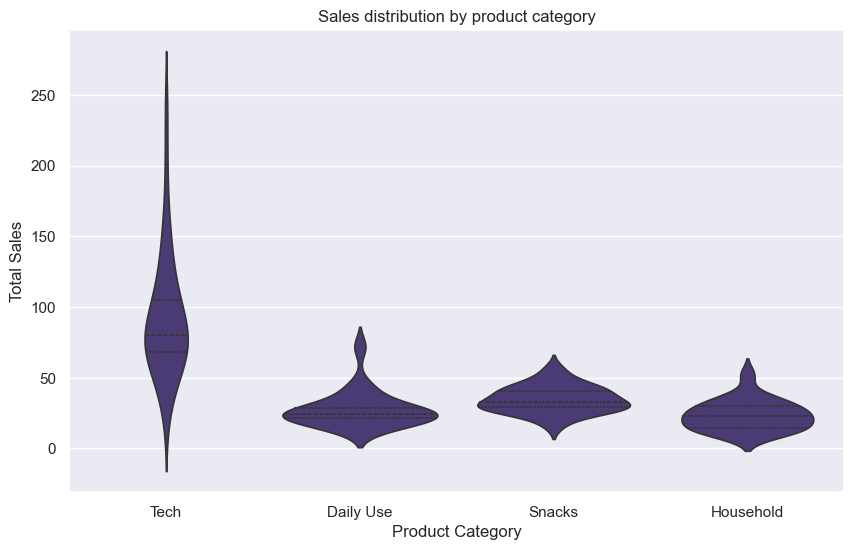

In [6]:
#Setting the theme for the charts
sns.set_theme(style='darkgrid', palette='viridis')

plt.figure(figsize=(10,6))
#A violin plot for the product category and total sales
sns.violinplot(data=df, x='Product Category',y='Total Sales', inner='quart')
plt.title('Sales distribution by product category')
plt.show()

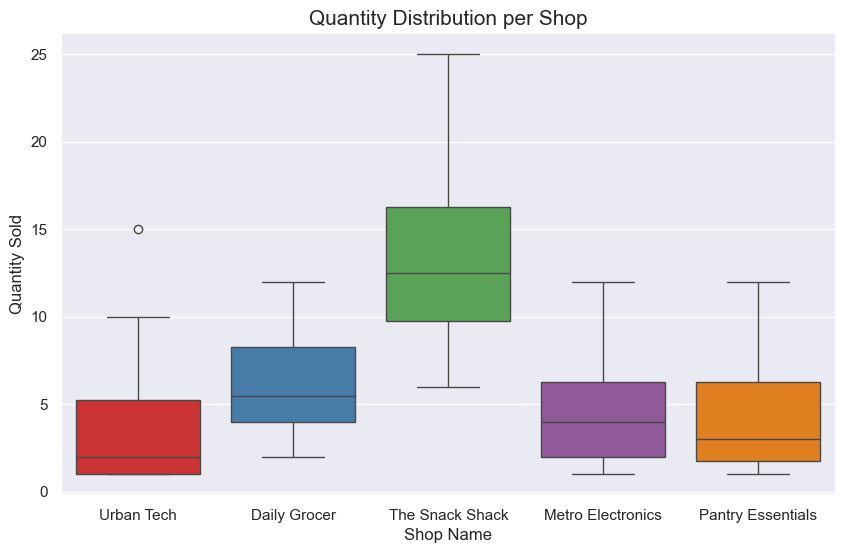

In [7]:
#a box plot for the shop performace by the qauntities sold
# plt.Figure(figsize=(16,6))
fig, ax = plt.subplots(figsize=(10,6))

sns.boxplot(data=df, x='Shop Name', y='Quantity Sold', ax=ax,hue='Shop Name', palette='Set1')
plt.title('Quantity Distribution per Shop',fontsize = 15)
# plt.xticks(rotation = 30)
plt.show()

#### Heat Map

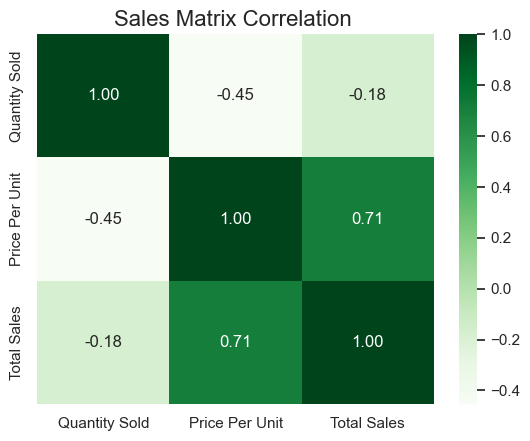

In [8]:
#create a only numeric dataframe
numeric_df = df[['Quantity Sold','Price Per Unit','Total Sales']]
numeric_matrix = numeric_df.corr()

#A HeatMap to show the correlation between the quantity sold, price per unit, and total sales
sns.heatmap(numeric_matrix, annot=True, cmap='Greens',fmt='.2f')
plt.title("Sales Matrix Correlation ",fontsize= 16)
plt.show()

In [9]:
#heat map for any one product category.
df['Product Category'].value_counts()

Product Category
Tech         40
Daily Use    20
Snacks       20
Household    20
Name: count, dtype: int64

In [10]:
# i will take Tech caterogry product.
tech_df = df[df['Product Category']== 'Tech']
tech_df.head()

,Shop Name,Product Name,Product Category,Quantity Sold,Price Per Unit,Total Sales
0,Urban Tech,Wireless Mouse,Tech,2,25.00,50.00
3,Metro Electronics,USB Cable,Tech,8,8.99,71.92
5,Urban Tech,Bluetooth Headphones,Tech,1,45.00,45.00
8,Metro Electronics,HDMI Cable,Tech,4,12.99,51.96
10,Urban Tech,Laptop Stand,Tech,1,35.50,35.50


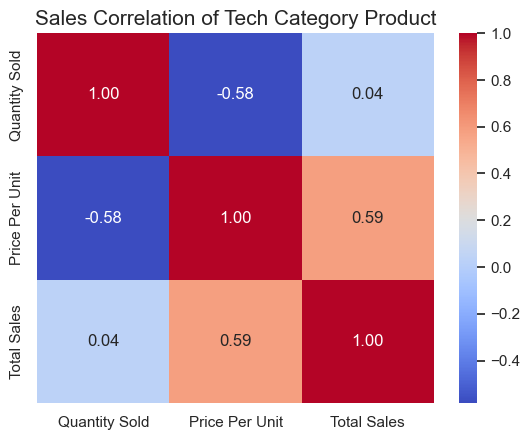

In [17]:
tech_corr_matrix = tech_df[['Quantity Sold','Price Per Unit', 'Total Sales']].corr()

#heatmap
plt.Figure(figsize=(10,6))

sns.heatmap(tech_corr_matrix,fmt='.2f', cmap='coolwarm', annot=True)
plt.title('Sales Correlation of Tech Category Product',fontsize =15 )
plt.show()

### A Multi Plot **DASHBOARD**

C:\Users\Mohith M\AppData\Local\Temp\ipykernel_15836\2257332022.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df,x='Product Category', y='Total Sales', ax=ax[0,0],palette='flare')
C:\Users\Mohith M\AppData\Local\Temp\ipykernel_15836\2257332022.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Product Category', y='Total Sales', ax=ax[1, 0], palette="pastel")
C:\Users\Mohith M\AppData\Local\Temp\ipykernel_15836\2257332022.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='Shop Name',y='Total Sales', ax=

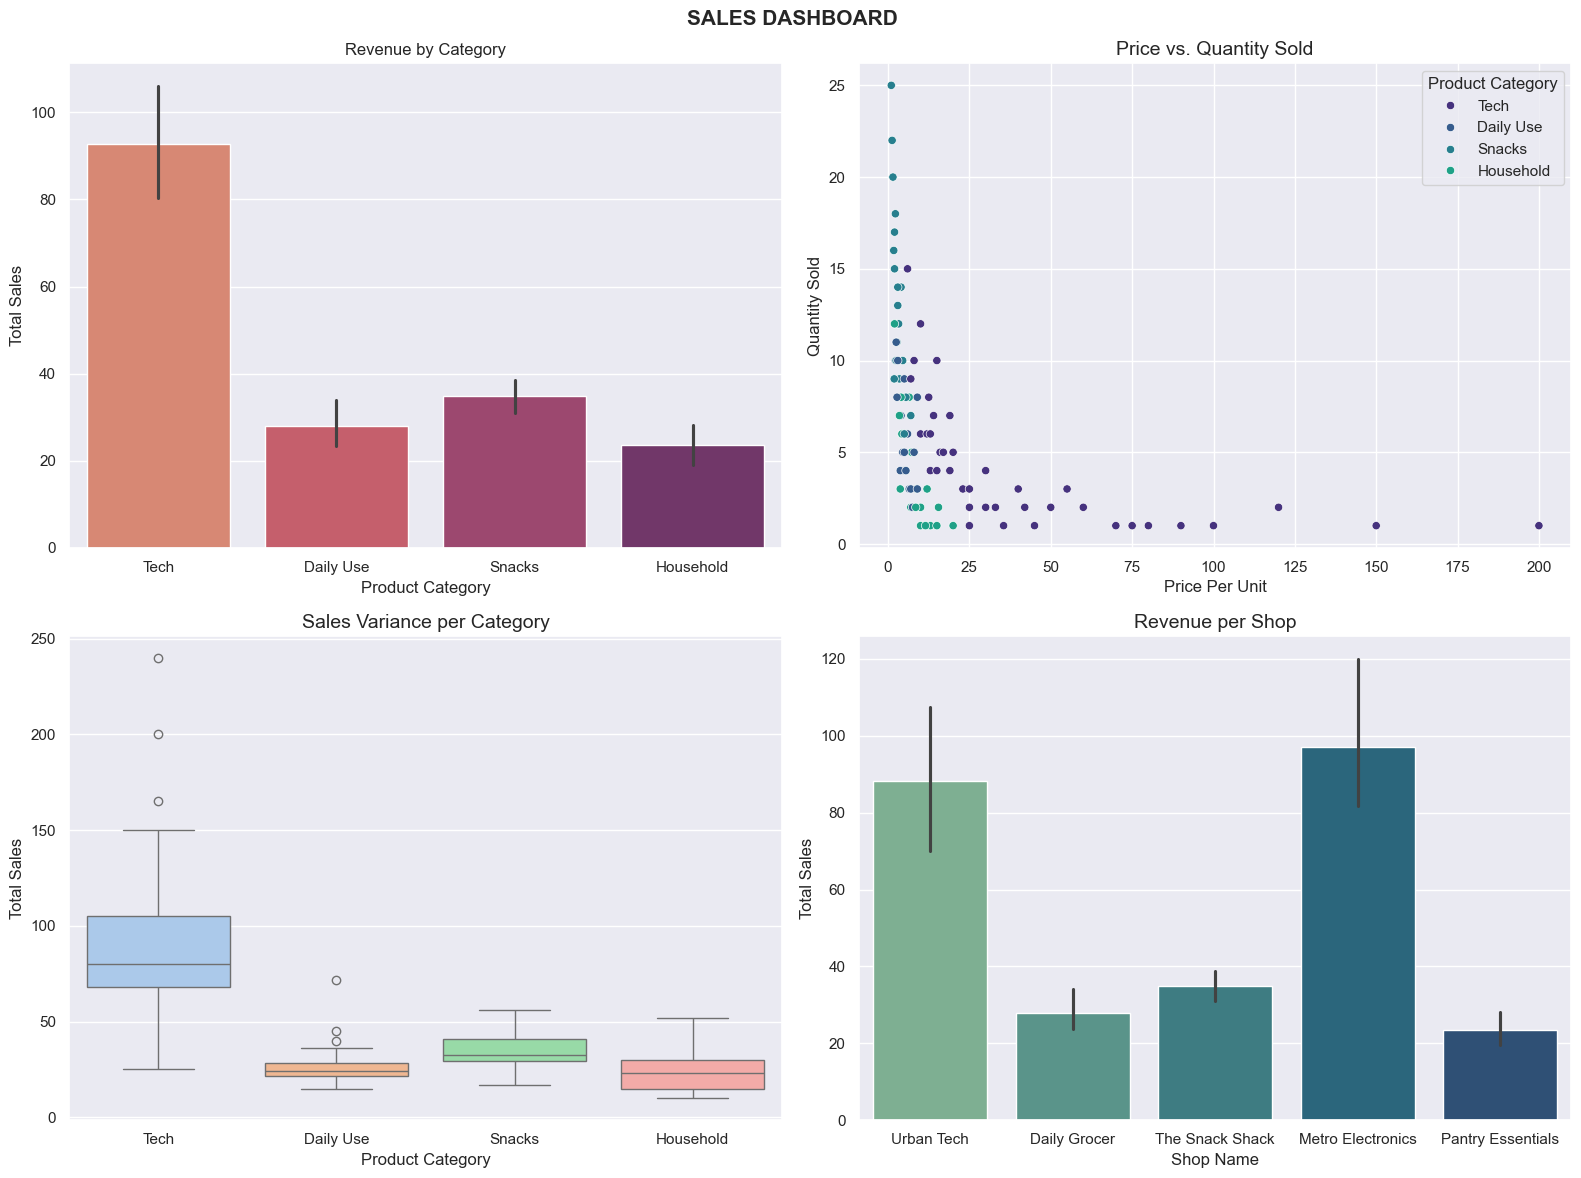

In [26]:
#2x2 grid creatation
fig, ax = plt.subplots(2,2, figsize=(16,12))
fig.suptitle("SALES DASHBOARD", fontsize=15, fontweight='bold')

#plot 1: Top Left- Total Sales by Product Category
sns.barplot(data=df,x='Product Category', y='Total Sales', ax=ax[0,0],palette='flare')
ax[0,0].set_title('Revenue by Category')

#plot 2: Top Right- Quantity vs price
sns.scatterplot(data=df, x='Price Per Unit', y='Quantity Sold', hue='Product Category', ax=ax[0, 1])
ax[0, 1].set_title('Price vs. Quantity Sold', fontsize=14)

# Plot 3: Bottom Left - Sales Distribution (Boxplot)
sns.boxplot(data=df, x='Product Category', y='Total Sales', ax=ax[1, 0], palette="pastel")
ax[1, 0].set_title('Sales Variance per Category', fontsize=14)

# Plot 4: Bottom Right - Shop Performance (Count Plot)
sns.barplot(data=df, x='Shop Name',y='Total Sales', ax=ax[1, 1], palette="crest")
ax[1, 1].set_title('Revenue per Shop', fontsize=14)

# Apply tight_layout to prevent overlapping
plt.tight_layout()
plt.show()